<a href="https://colab.research.google.com/github/rizbuy/Analisis-Data-Dicoding/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Rizky Maulana Ayub
- **Email:** rizkymaulanaayub@gmail.com
- **ID Dicoding:** rizbuy

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penyewaan sepeda per bulan pada tahun 2010 dan 2011?
- bagaimana performa penyewaan sepeda pada working day dan non working day(termasuk holidah dan weekend)

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

### Gathering Data

In [ ]:
daily_df = pd.read_csv('https://raw.githubusercontent.com/rizbuy/Analisis-Data-Dicoding/refs/heads/main/day.csv', encoding = 'latin-1')
daily_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

In [ ]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
daily_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
daily_df.duplicated().sum()

np.int64(0)

In [ ]:
daily_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
hourly_df = pd.read_csv('https://raw.githubusercontent.com/rizbuy/Analisis-Data-Dicoding/refs/heads/main/hour.csv', encoding = 'latin-1')
hourly_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
hourly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
hourly_df.duplicated().sum()
hourly_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Data hourly_df dan daily_df tidak memiliki missing value dan duplicated value
- Terdapat kesalahan dalam format tanggal
- Terdapat nilai yang membingungkan seperti kolom tahun yang isinya 0 dan 1, kolom season yang isinya data numerik 1 - 4, dan nilai temp, atemp, hum, dan windspeed yang terlihat aneh


### Cleaning Data

In [ ]:
#Merubah format kolom dteday dan mengganti nilai kolom yr menjadi tahun yang benar
dataframes = [daily_df, hourly_df]
denorm_factors = {'temp': 41, 'atemp': 50, 'hum': 100, 'windspeed': 67}

for df in dataframes:
  if 'dteday' in df.columns:
    df['dteday'] = pd.to_datetime(df['dteday'], format='%Y-%m-%d')
  if 'yr' in df.columns:
    df['yr'] = df['yr'].replace({0: 2011, 1: 2012})
  if 'weathersit' in df.columns:
    df['weathersit'] = df['weathersit'].replace({1: 'Clear', 2: 'Mist', 3: 'Light Snow', 4: 'Heavy Rain'})
  if 'season' in df.columns:
    df['season'] = df['season'].replace({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
  if 'mnth' in df.columns:
    df['mnth'] = df['mnth'].replace({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})
  #Denormalize value
  for col, factor in denorm_factors.items():
      if col in df.columns:
          df[col] = df[col] * factor

In [ ]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [ ]:
hourly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Format data telah diperbaiki
- Nilai yang terlihat aneh telah diperbaiki

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
daily_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731.000000,731,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,12,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,Jan,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,62,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,2011.500684,NaN,0.028728,2.997264,0.683995,NaN,20.310776,23.717699,62.789406,12.762576,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,0.000000,0.000000,NaN,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,2011.000000,NaN,0.000000,1.000000,0.000000,NaN,13.820424,16.892125,52.000000,9.041650,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,2012.000000,NaN,0.000000,3.000000,1.000000,NaN,20.431653,24.336650,62.666700,12.125325,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,2012.000000,NaN,0.000000,5.000000,1.000000,NaN,26.872076,30.430100,73.020850,15.625371,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,2012.000000,NaN,1.000000,6.000000,1.000000,NaN,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
hourly_df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,12,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,Jul,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,1488,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,2011.502561,NaN,11.546752,0.028770,3.003683,0.682721,NaN,20.376474,23.788755,62.722884,12.736540,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,2011.000000,NaN,6.000000,0.000000,1.000000,0.000000,NaN,13.940000,16.665000,48.000000,7.001500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,2012.000000,NaN,12.000000,0.000000,3.000000,1.000000,NaN,20.500000,24.240000,63.000000,12.998000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,2012.000000,NaN,18.000000,0.000000,5.000000,1.000000,NaN,27.060000,31.060000,78.000000,16.997900,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,2012.000000,NaN,23.000000,1.000000,6.000000,1.000000,NaN,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
monthly_rentals = (daily_df.groupby(['yr','mnth'])['cnt']
                   .agg(
                       total_rentals = 'sum',
                       average_rentals='mean',
                       max_rental='max',
                       min_rentals='min'
                   )
                   .sort_values(by='total_rentals', ascending=False)
                   .reset_index()
)
monthly_rentals

,yr,mnth,total_rentals,average_rentals,max_rental,min_rentals
0,2012,Sep,218573,7285.766667,8714,4073
1,2012,Aug,214503,6919.451613,7865,4549
2,2012,Jul,203607,6567.967742,8173,4459
3,2012,Jun,202830,6761.000000,8120,4127
4,2012,Oct,198841,6414.225806,8156,22
5,2012,May,195865,6318.225806,8294,2843
6,2012,Apr,174224,5807.466667,7460,1027
7,2012,Mar,164875,5318.548387,8362,3194
8,2012,Nov,152664,5088.800000,6852,2277
9,2011,Jun,143512,4783.733333,5515,3767


In [ ]:
# Recalculate yearly_rentals from the updated daily_df
yearly_rentals = (daily_df.groupby(['yr'])['cnt']
                   .agg(
                       total_rentals = 'sum',
                       average_rentals='mean',
                       max_rental='max',
                       min_rentals='min'
                   )
                   .sort_values(by='total_rentals', ascending=False)
                   .reset_index()
)
print('Jumlah penyewa tahunan:')
# Sederhanakan pencetakan dengan to_string()
print(yearly_rentals.to_string(index=False))

Jumlah penyewa tahunan:
  yr  total_rentals  average_rentals  max_rental  min_rentals
2012        2049576      5599.934426        8714           22
2011        1243103      3405.761644        6043          431


In [ ]:
# Correct the weekday mapping and order
daily_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Map numerical weekday to names and categorize the column
daily_df['weekday'] = daily_df['weekday'].map({0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'})
daily_df['weekday'] = pd.Categorical(daily_df['weekday'], categories=daily_order, ordered=True)

/tmp/ipython-input-263-1541598358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_rentals = (daily_df.groupby(['yr','weekday'])['cnt']


Text(0, 0.5, 'Total Rental')

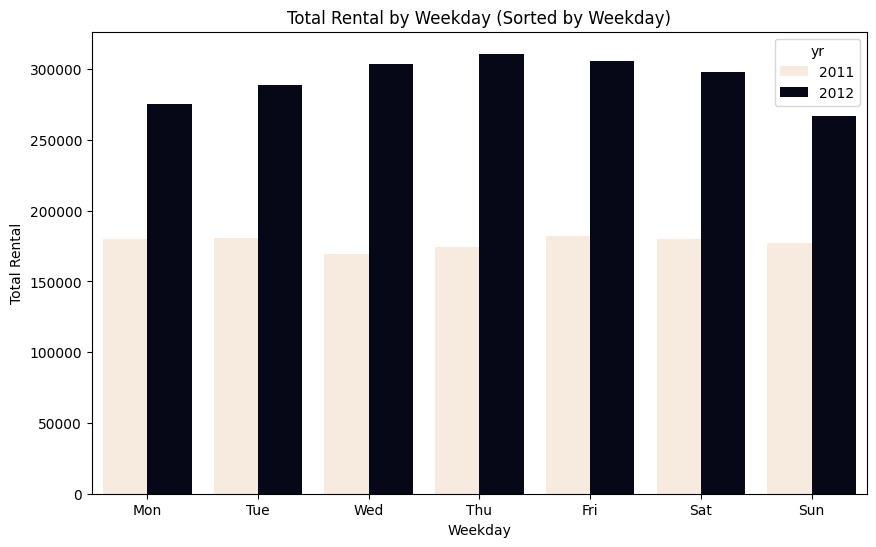

In [ ]:
weekly_rentals = (daily_df.groupby(['yr','weekday'])['cnt']
                   .agg(
                       total_rentals = 'sum',
                       average_rentals='mean',
                       max_rental='max',
                       min_rentals='min'
                   )
                   .sort_values(by='weekday', ascending=False)
                   .reset_index()
)
weekly_rentals

plt.figure(figsize=(10, 6))
sns.barplot(x='weekday', y='total_rentals', hue='yr', data=weekly_rentals, palette='rocket_r')
plt.title('Total Rental by Weekday (Sorted by Weekday)')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Weekday')
plt.ylabel('Total Rental')

**Insight:**
- Jumlah sewa terbanyak terjadi pada bulan September Tahun 2012, dengan total 218.573 sepeda dan yang paling sedikit adalah bulan Januari Tahun 2011 dengan total 38.189 sepeda
- Secara visual terlihat bahwa penyewaan pada tahun 2011 lebih rendah dibandingkan dengan tahun 2012. Jumlah penyewaan sepeda terbanyak terjadi pada tahun 2012 sebanyak 2.049.576 sedangkan pada tahun 2011 jumlah penyewa sebanyak  1.243.103.

    hr  total_rentals  average_rentals  max_rental  min_rentals
0    0          39130        53.898072         283            2
1    1          24164        33.375691         168            1
2    2          16352        22.869930         132            1
3    3           8174        11.727403          79            1
4    4           4428         6.352941          28            1
5    5          14261        19.889819          66            1
6    6          55132        76.044138         213            1
7    7         154171       212.064649         596            1
8    8         261001       359.011004         839            5
9    9         159438       219.309491         426           14
10  10         126257       173.668501         539            8
11  11         151320       208.143054         663           10
12  12         184414       253.315934         776            3
13  13         184919       253.661180         760           11
14  14         175652       240.949246  

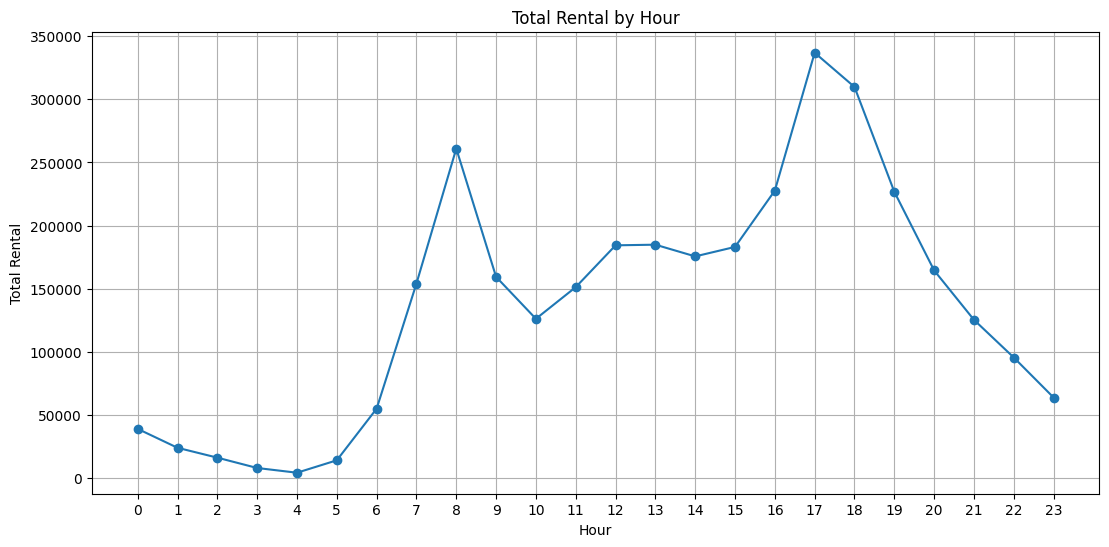

In [ ]:
hourly_rentals = (hourly_df.groupby(['hr'])['cnt']
                  .agg
                  (
                      total_rentals = 'sum',
                      average_rentals='mean',
                      max_rental='max',
                      min_rentals='min'
                  ).reset_index().sort_values(by='hr')
)
print(hourly_rentals)
plt.figure(figsize=(13,6))
plt.plot(hourly_rentals['hr'], hourly_rentals['total_rentals'], marker='o', linestyle='-')
plt.title('Total Rental by Hour')
plt.xlabel('Hour')
plt.xticks(hourly_rentals['hr'])
plt.ylabel('Total Rental')
plt.grid(True)
plt.show()

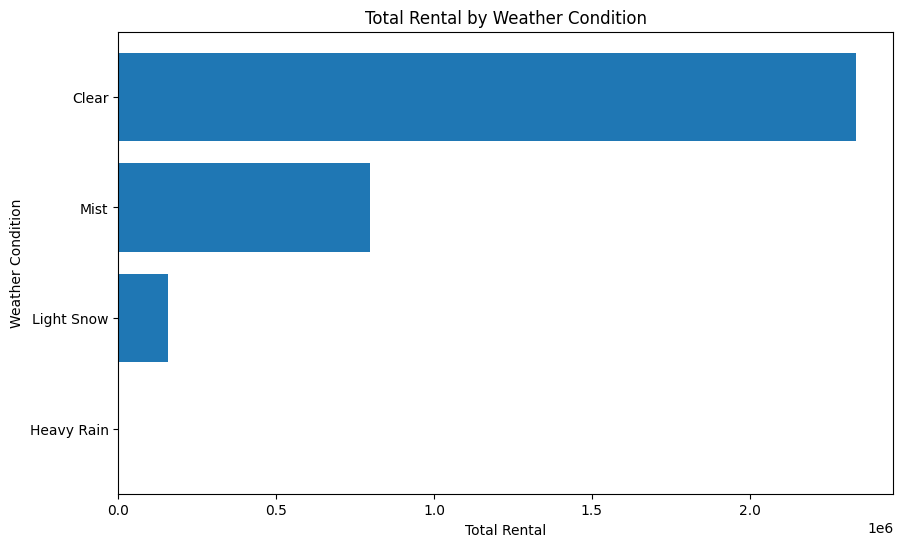

In [ ]:
weather_rentals = (hourly_df.groupby(['weathersit'])['cnt']
                                    .agg(
                                        total_rentals = 'sum',
                                        average_rentals = 'mean',
                                        max_rentals = 'max',
                                        min_rentals = 'min'
                                    ).sort_values(by='total_rentals')
                                    .reset_index())
weather_rentals

plt.figure(figsize=(10, 6))
plt.barh(weather_rentals['weathersit'], weather_rentals['total_rentals'])
plt.xlabel('Total Rental')
plt.ylabel('Weather Condition')
plt.title('Total Rental by Weather Condition')
plt.show()

Insight
- Data cuaca merupakan data yang mempengaruhi jumlah penyewaan sepeda per hari.
cuaca yang cerah meningkatkan jumlah penyewaan sepeda dan sebaliknya semaki cuaca memburuk penyewaan berkurang.

Action
- Integrasikan laporan cuaca harian dengan persiapan armada sepeda yang memadai
sehingga ketika laporan cuaca mengatakan bahwa hari akan cerah armada sepeda telah siap.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Tabel Jumlah Total Sewa per Bulan (diurutkan berdasarkan bulan):
  yr mnth  total_rentals  average_rentals  max_rental  min_rentals
2011  Jan          38189      1231.903226        1985          431
2011  Feb          48215      1721.964286        2927         1005
2011  Mar          64045      2065.967742        3239          605
2011  Apr          94870      3162.333333        5312          795
2011  May         135821      4381.322581        5805         2633
2011  Jun         143512      4783.733333        5515         3767
2011  Jul         141341      4559.387097        6043         3285
2011  Aug         136691      4409.387097        5895         1115
2011  Sep         127418      4247.266667        5423         1842
2011  Oct         123511      3984.225806        5511          627
2011  Nov         102167      3405.566667        4486         1495
2011  Dec          87323      2816.870968        3940          705
2012  Jan          96744      3120.774194        4521         13

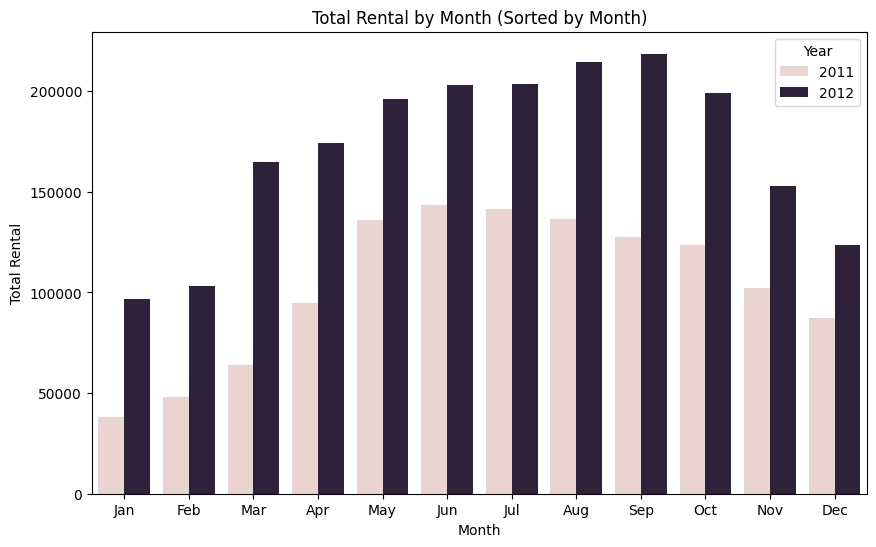

In [ ]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_rentals = (
    daily_df.groupby(['yr', 'mnth'])['cnt']
    .agg(
        total_rentals = 'sum',
        average_rentals='mean',
        max_rental='max',
        min_rentals='min'
    )
    .reset_index()
)

monthly_rentals['mnth'] = pd.Categorical(monthly_rentals['mnth'], categories=month_order, ordered=True)

monthly_rentals_sorted = monthly_rentals.sort_values(by=['yr', 'mnth'])

print("Tabel Jumlah Total Sewa per Bulan (diurutkan berdasarkan bulan):")
print(monthly_rentals_sorted.to_string(index=False))


plt.figure(figsize=(10, 6))
sns.barplot(x='mnth', y='total_rentals', hue='yr', data=monthly_rentals_sorted)
plt.title('Total Rental by Month (Sorted by Month)')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Month')
plt.ylabel('Total Rental')
plt.legend(title='Year')
plt.show()

### Pertanyaan 2:

                    day_type  total_rentals
0                Working Day        2292410
1  Non-Working Day / Holiday        1000269


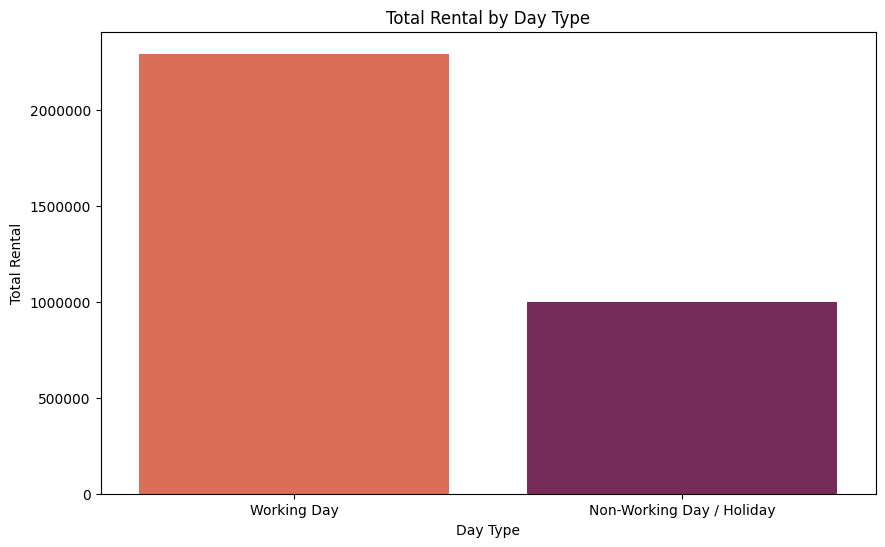

In [ ]:
# Hitung total sewa untuk hari kerja (workingday == 1)
working_day_sum = daily_df[daily_df['workingday'] == 1]['cnt'].sum()

# Hitung total sewa untuk hari NON-KERJA (workingday == 0).
# Ini secara otomatis akan mencakup akhir pekan DAN hari libur yang ditandai sebagai workingday=0.
non_working_day_sum = daily_df[daily_df['workingday'] == 0]['cnt'].sum()

# Buat DataFrame perbandingan
comparison_data = {
    'day_type': ['Working Day', 'Non-Working Day / Holiday'],
    'total_rentals': [working_day_sum, non_working_day_sum]
}
comparison_df = pd.DataFrame(comparison_data)

print(comparison_df.head())

plt.figure(figsize=(10, 6))
sns.barplot(x='day_type', y='total_rentals', data=comparison_df, hue=comparison_data['day_type'], palette='rocket_r')
plt.title('Total Rental by Day Type')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Day Type')
plt.ylabel('Total Rental')
plt.show()


Perbandingan Sewa antara Hari Libur Nasional dan Akhir Pekan:
           day_type  total_rentals
0  National Holiday          78435
1           Weekend         921834


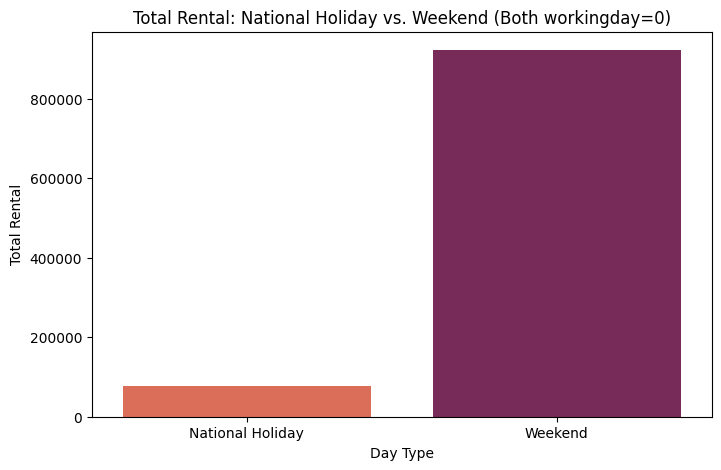

In [ ]:
# Filter data untuk workingday = 0 (hari non-kerja/libur) dan holiday = 1 (hari libur nasional)
holiday_rentals = daily_df[(daily_df['workingday'] == 0) & (daily_df['holiday'] == 1)]['cnt'].sum()

# Filter data untuk workingday = 0 (hari non-kerja/libur) dan holiday = 0 (akhir pekan)
weekend_rentals = daily_df[(daily_df['workingday'] == 0) & (daily_df['holiday'] == 0)]['cnt'].sum()

# Buat DataFrame perbandingan antara hari libur nasional dan akhir pekan (keduanya workingday=0)
comparison_data_holiday_weekend = {
    'day_type': ['National Holiday', 'Weekend'],
    'total_rentals': [holiday_rentals, weekend_rentals]
}
comparison_df_holiday_weekend = pd.DataFrame(comparison_data_holiday_weekend)

print("\nPerbandingan Sewa antara Hari Libur Nasional dan Akhir Pekan:")
print(comparison_df_holiday_weekend.head())

# Visualisasikan perbandingan
plt.figure(figsize=(8, 5))
sns.barplot(x='day_type', y='total_rentals', data=comparison_df_holiday_weekend, hue=comparison_data_holiday_weekend['day_type'], palette='rocket_r')
plt.title('Total Rental: National Holiday vs. Weekend (Both workingday=0)')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Day Type')
plt.ylabel('Total Rental')
plt.show()


Perbandingan Sewa antara Hari Libur Nasional dan Akhir Pekan:
           day_type  total_rentals
0  National Holiday          78435
1           Weekend         921834


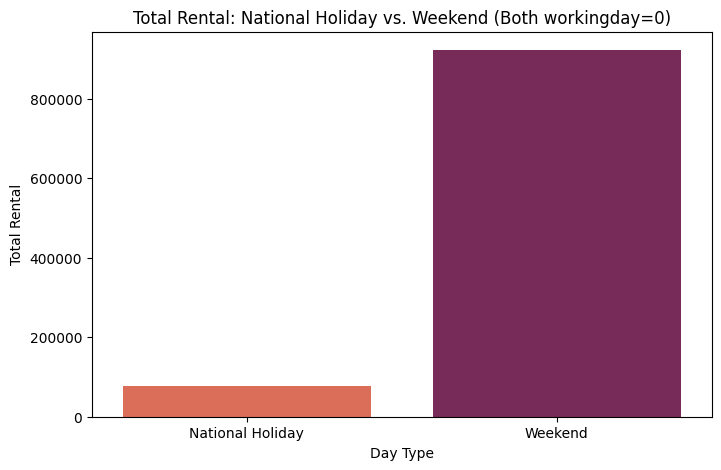

In [ ]:
# Filter data untuk workingday = 0 (hari non-kerja/libur) dan holiday = 1 (hari libur nasional)
holiday_rentals = daily_df[(daily_df['workingday'] == 0) & (daily_df['holiday'] == 1)]['cnt'].sum()

# Filter data untuk workingday = 0 (hari non-kerja/libur) dan holiday = 0 (akhir pekan)
weekend_rentals = daily_df[(daily_df['workingday'] == 0) & (daily_df['holiday'] == 0)]['cnt'].sum()

# Buat DataFrame perbandingan antara hari libur nasional dan akhir pekan (keduanya workingday=0)
comparison_data_holiday_weekend = {
    'day_type': ['National Holiday', 'Weekend'],
    'total_rentals': [holiday_rentals, weekend_rentals]
}
comparison_df_holiday_weekend = pd.DataFrame(comparison_data_holiday_weekend)

print("\nPerbandingan Sewa antara Hari Libur Nasional dan Akhir Pekan:")
print(comparison_df_holiday_weekend.head())

# Visualisasikan perbandingan
plt.figure(figsize=(8, 5))
sns.barplot(x='day_type', y='total_rentals', data=comparison_df_holiday_weekend, hue=comparison_data_holiday_weekend['day_type'], palette='rocket_r')
plt.title('Total Rental: National Holiday vs. Weekend (Both workingday=0)')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Day Type')
plt.ylabel('Total Rental')
plt.show()

**Insight:**
- Data menunjukkan bahwa penyewaan sepeda ketika hari kerja lebih tinggi daripada hari libur. Ini mengindikasikan bahwa mayoritas penyewa menggunakan sepedanya untuk berangkat kerja.
- Pada hari libur nasional penyewaan sepeda lebih sedikit dibandingkan ketika weekend. Hal ini mengindikasikan bahwa sebagian besar penyewa lebih suka menyewa ketika weekend dan melakukan kegiatan lain pada libur nasional
- Trivia:apakah sepeda termasuk sarana olahraga atau transportasi. masuknya pajak kendaraan atau pajak olahraga?

        average_atemp
season               
Fall        32.794920
Summer      26.015366
Winter      20.776937
Spring      14.845697


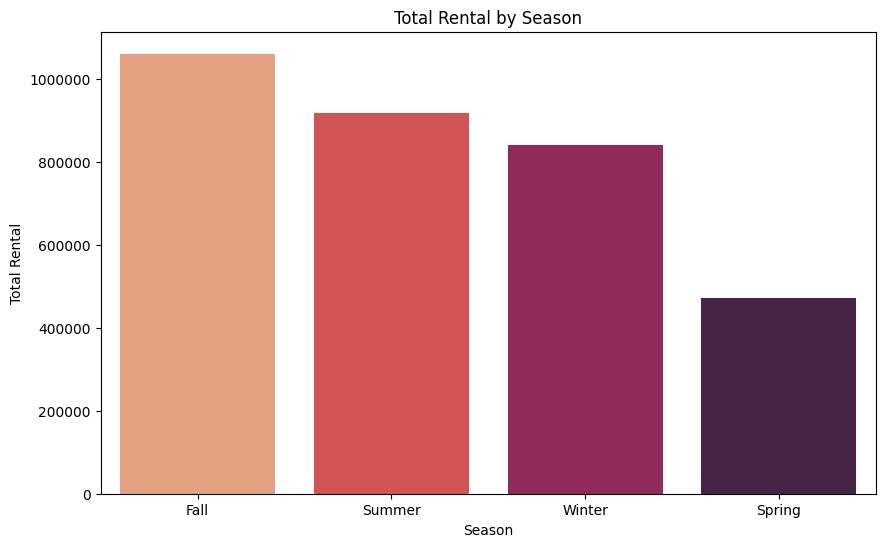

In [ ]:
seasonal_df = (daily_df.groupby('season')['cnt']
                .agg(
                  total_rentals = 'sum',
                  max_rental='max',
                  min_rentals='min'
                )
                .sort_values(by='total_rentals',ascending=False))
seasonal_df

monthly_atemp = (daily_df.groupby('season')['atemp']
                .agg(
                  average_atemp = 'mean'
                )
                .sort_values(by='average_atemp',ascending=False))
print(monthly_atemp)

plt.figure(figsize=(10, 6))
sns.barplot(x=seasonal_df.index, y=seasonal_df['total_rentals'], hue=seasonal_df.index, palette='rocket_r')
plt.title('Total Rental by Season')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Season')
plt.ylabel('Total Rental')
plt.show()

**Insight:**
- Penyewaan sepeda terbanyak terjadi pada musim gugur dan yang paling rendah adalah musim semi. dan berdasarkan data atemp ditemukan bahwa musim semi adalah musimd dengan rata-rata suhu terhangat.

## Analisis Lanjutan (Opsional)

Total Sewa per Kategori Jam:
hour_category
Sore     1101169
Siang    1005711
Pagi      629742
Malam     449548
Fajar     106509
Name: cnt, dtype: int64

Total Sewa per Kategori Jam per Hari:
hour_category  Fajar    Pagi   Siang    Sore  Malam
dteday                                             
Friday         13097  110825  135906  160832  67130
Monday          9707  100364  115535  167728  62169
Saturday       26382   38664  222269  128884  61608
Sunday         29160   30211  214139  123089  47428
Thursday       10447  117587  109323  174116  73922
Tuesday         8091  113672  102910  177057  67379
Wednesday       9625  118419  105629  169463  69912


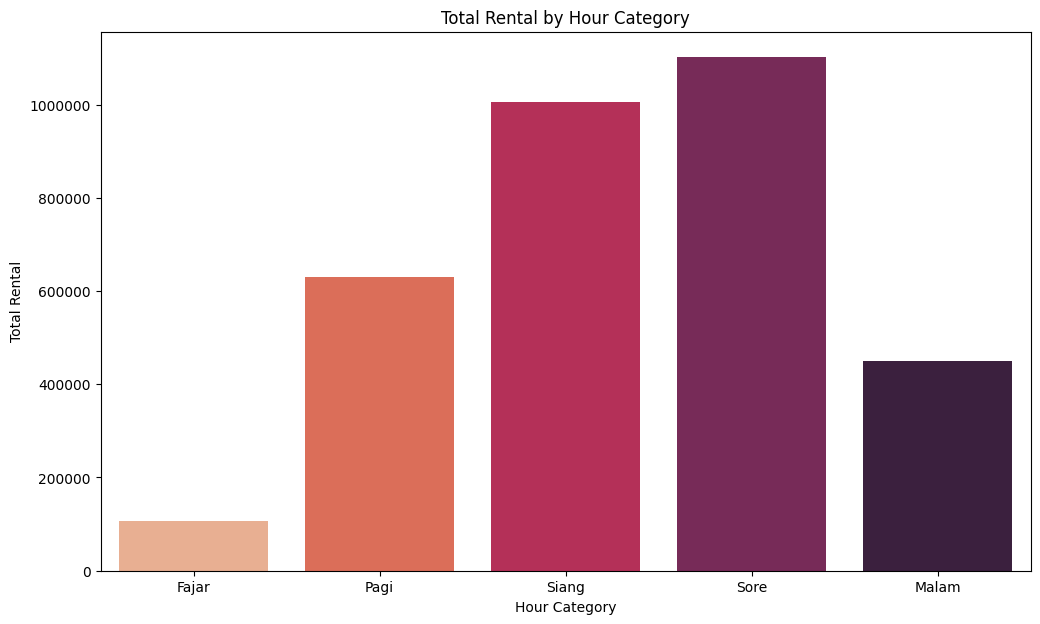

In [ ]:
# Penerapan Teknik Binning pada kolom 'hr'
hourly_df['hour_category'] = pd.cut(hourly_df['hr'],
                                    bins=[0, 6, 10, 16, 20, 24],
                                    labels=['Fajar','Pagi','Siang','Sore','Malam'],
                                    right=False,
                                    include_lowest=True) # Include the lowest value in the first bin

hourly_rentals_by_hour_category = hourly_df.groupby('hour_category', observed=False)['cnt'].sum().sort_values(ascending=False)

# Hitung total sewa per kategori jam, dikelompokkan berdasarkan hari dalam seminggu
hour_category_per_daily = hourly_df.groupby([hourly_df['dteday'].dt.day_name(), 'hour_category'], observed=False)['cnt'].sum().unstack()

print("Total Sewa per Kategori Jam:")
print(hourly_rentals_by_hour_category)

print("\nTotal Sewa per Kategori Jam per Hari:")
print(hour_category_per_daily)


plt.figure(figsize=(12, 7))
sns.barplot(x=hourly_rentals_by_hour_category.index, y=hourly_rentals_by_hour_category.values, hue=hourly_rentals_by_hour_category.index, palette='rocket_r')
plt.title('Total Rental by Hour Category')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.xlabel('Hour Category')
plt.ylabel('Total Rental')
plt.show()

**Insight:**
- Waktu dengan jumlah terbanyak orang menyewa sepeda adalah Sore, Waktu dengan jumlah penyewa tersedikit adalah Fajar. Bukankah normalnya fajar adalah waktu tidur.

## Conclusion

- Conclusion pertanyaan 1
*Performa Penyewaan Sepeda per Bulan (2011 vs. 2012)
Secara keseluruhan, performa penyewaan sepeda pada tahun 2012 jauh melampaui tahun 2011. Tahun 2012 mencatat total 2.049.576 sewa, sementara tahun 2011 hanya 1.243.103. Puncak penyewaan terjadi pada September 2012 (218.573 sepeda), sedangkan bulan dengan penyewaan terendah adalah Januari 2011 (38.189 sepeda). Pola ini menunjukkan pertumbuhan signifikan dari tahun ke tahun, dengan peningkatan permintaan yang jelas di tahun 2012, terutama di bulan-bulan menjelang akhir tahun.
- Conclution pertanyaan 2
*Data dengan jelas menunjukkan bahwa penyewaan sepeda lebih tinggi pada hari kerja (working day) dibandingkan hari libur (termasuk weekend dan hari libur nasional). Ini sangat mengindikasikan bahwa mayoritas pengguna menyewa sepeda untuk keperluan komuter atau transportasi sehari-hari menuju/dari tempat kerja. Menariknya, penyewaan pada hari libur nasional lebih rendah daripada weekend, menyiratkan bahwa pengguna lebih cenderung menggunakan sepeda untuk kegiatan rekreasi atau santai di akhir pekan, dan mungkin memiliki preferensi aktivitas lain saat libur nasional.

Rekomendasi Aksi
- Manfaatkan Peningkatan Popularitas Akhir Tahun dan Tahun Berikutnya:

- Lakukan kampanye pemasaran atau promosi khusus menjelang dan selama bulan-bulan puncak penyewaan (misalnya, Agustus-Oktober), belajar dari performa tahun 2012.

- Siapkan armada sepeda yang memadai untuk mengantisipasi lonjakan permintaan di bulan-bulan tersebut, terutama di tahun-tahun mendatang jika tren ini terus berlanjut.

- Tingkatkan ketersediaan sepeda dan stasiun docking di area perkantoran atau pusat komersial selama jam-jam sibuk hari kerja (pagi dan sore).

- Pertimbangkan program loyalitas atau diskon untuk penyewa harian/bulanan yang menggunakan sepeda untuk komuter.

- Optimalkan pemeliharaan sepeda agar selalu dalam kondisi prima, terutama untuk penggunaan rutin harian.